In [1]:
import distutils.util
import os
import subprocess

# @title Import packages for plotting and creating graphics
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

import mediapy as media
import matplotlib.pyplot as plt

# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from brax.training.agents.sac import train as sac_train
from brax.training.agents.sac import networks as sac_networks
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

#@title Import The Playground

from mujoco_playground import wrapper
from mujoco_playground import registry

In [2]:
registry.locomotion.ALL_ENVS


('ApolloJoystickFlatTerrain',
 'BarkourJoystick',
 'BerkeleyHumanoidJoystickFlatTerrain',
 'BerkeleyHumanoidJoystickRoughTerrain',
 'G1JoystickFlatTerrain',
 'G1JoystickRoughTerrain',
 'Go1JoystickFlatTerrain',
 'Go1JoystickRoughTerrain',
 'Go1Getup',
 'Go1Handstand',
 'Go1Footstand',
 'H1InplaceGaitTracking',
 'H1JoystickGaitTracking',
 'Op3Joystick',
 'SpotFlatTerrainJoystick',
 'SpotGetup',
 'SpotJoystickGaitTracking',
 'T1JoystickFlatTerrain',
 'T1JoystickRoughTerrain',
 'PupperJoystickFlatTerrain',
 'PupperJoystickSacFlatTerrain',
 'PupperJoystickWithGun',
 'PupperGetup')

In [3]:
env_name = 'PupperJoystickSacFlatTerrain'# PupperJoystickSacFlatTerrain
env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)
env_cfg

Kd: 0.5
Kp: 35.0
action_repeat: 1
action_scale: 0.5
command_config:
  a:
  - 0.4
  - 0.7
  - 0.4
  b:
  - 0.25
  - 0.9
  - 0.5
ctrl_dt: 0.02
episode_length: 1000
history_len: 1
noise_config:
  level: 1.0
  scales:
    gravity: 0.05
    gyro: 0.2
    joint_pos: 0.03
    joint_vel: 1.5
    linvel: 0.1
pert_config:
  enable: true
  kick_durations:
  - 0.05
  - 0.2
  kick_wait_times:
  - 1.0
  - 3.0
  velocity_kick:
  - 0.0
  - 3.0
reward_config:
  max_foot_height: 0.06
  scales:
    action_rate: -0.01
    ang_vel_xy: -0.5
    dof_pos_limits: -1.0
    energy: -0.001
    feet_air_time: 0.2
    feet_clearance: -2.0
    feet_height: -0.2
    feet_slip: -0.1
    lin_vel_z: -0.5
    orientation: -5.0
    pose: 2.5
    stand_still: -1.0
    termination: -1.0
    torques: -0.0001
    tracking_ang_vel: 1.0
    tracking_lin_vel: 2.2
  tracking_sigma: 0.25
sim_dt: 0.004
soft_joint_pos_limit_factor: 0.95

In [4]:
from mujoco_playground.config import locomotion_params
sac_params = locomotion_params.brax_sac_config(env_name)
sac_params

action_repeat: 1
batch_size: 512
deterministic_eval: true
discounting: 0.99
episode_length: 1000
grad_updates_per_step: 32
learning_rate: 0.0003
max_replay_size: 1048576
min_replay_size: 16384
network_factory:
  hidden_layer_sizes: !!python/tuple
  - 512
  - 256
  - 128
normalize_observations: true
num_envs: 8192
num_eval_envs: 128
num_evals: 64
num_timesteps: 100000000
reward_scaling: 20.0
seed: 0
tau: 0.005

In [5]:
registry.get_domain_randomizer(env_name)

<function mujoco_playground._src.locomotion.pupper.randomize.domain_randomize(model: mujoco.mjx._src.types.Model, rng: jax.Array)>

In [6]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, sac_params["num_timesteps"] * 1.25])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

sac_training_params = dict(sac_params)
network_factory = sac_networks.make_sac_networks
if "network_factory" in sac_params:
  del sac_training_params["network_factory"]
  network_factory = functools.partial(
      sac_networks.make_sac_networks,
      **sac_params.network_factory
  )

train_fn = functools.partial(
    sac.train, **dict(sac_training_params),
    network_factory=network_factory,
    progress_fn=progress
)
     

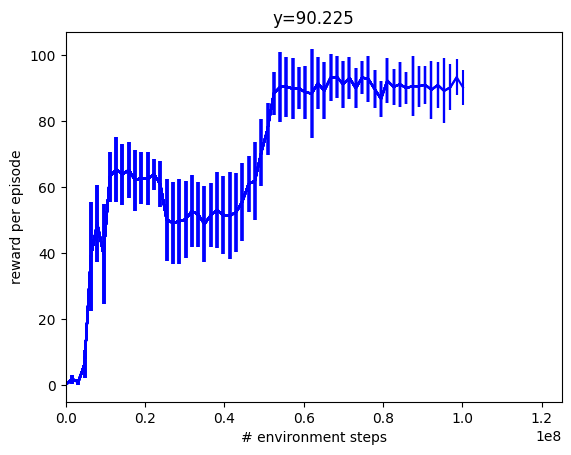

time to jit: 0:01:29.065981
time to train: 0:09:30.146172


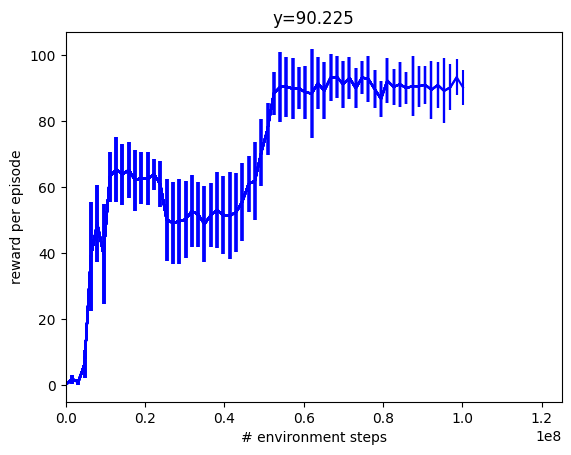

In [7]:
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [8]:
# Enable perturbation in the eval env.
env_cfg = registry.get_default_config(env_name)
env_cfg.pert_config.enable = True
env_cfg.pert_config.velocity_kick = [3.0, 6.0]
env_cfg.pert_config.kick_wait_times = [5.0, 15.0]
env_cfg.command_config.a = [1.5, 0.8, 2*jp.pi]
eval_env = registry.load(env_name, config=env_cfg)
velocity_kick_range = [0.0, 0.0]  # Disable velocity kick.
kick_duration_range = [0.05, 0.2]

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [9]:
#@title Rollout and Render
from mujoco_playground._src.gait import draw_joystick_command

x_vel = 0.0  #@param {type: "number"}
y_vel = -0.7  #@param {type: "number"}
yaw_vel = 0.0  #@param {type: "number"}


def sample_pert(rng):
  rng, key1, key2 = jax.random.split(rng, 3)
  pert_mag = jax.random.uniform(
      key1, minval=velocity_kick_range[0], maxval=velocity_kick_range[1]
  )
  duration_seconds = jax.random.uniform(
      key2, minval=kick_duration_range[0], maxval=kick_duration_range[1]
  )
  duration_steps = jp.round(duration_seconds / eval_env.dt).astype(jp.int32)
  state.info["pert_mag"] = pert_mag
  state.info["pert_duration"] = duration_steps
  state.info["pert_duration_seconds"] = duration_seconds
  return rng


rng = jax.random.PRNGKey(0)
rollout = []
modify_scene_fns = []

swing_peak = []
rewards = []
linvel = []
angvel = []
track = []
foot_vel = []
rews = []
contact = []
command = jp.array([x_vel, y_vel, yaw_vel])

state = jit_reset(rng)
if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
  rng = sample_pert(rng)
state.info["command"] = command
for i in range(env_cfg.episode_length):
  if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
    rng = sample_pert(rng)
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  state.info["command"] = command
  rews.append(
      {k: v for k, v in state.metrics.items() if k.startswith("reward/")}
  )
  rollout.append(state)
  swing_peak.append(state.info["swing_peak"])
  rewards.append(
      {k[7:]: v for k, v in state.metrics.items() if k.startswith("reward/")}
  )
  linvel.append(env.get_global_linvel(state.data))
  angvel.append(env.get_gyro(state.data))
  track.append(
      env._reward_tracking_lin_vel(
          state.info["command"], env.get_local_linvel(state.data)
      )
  )

  feet_vel = state.data.sensordata[env._foot_linvel_sensor_adr]
  vel_xy = feet_vel[..., :2]
  vel_norm = jp.sqrt(jp.linalg.norm(vel_xy, axis=-1))
  foot_vel.append(vel_norm)

  contact.append(state.info["last_contact"])

  xyz = np.array(state.data.xpos[env._torso_body_id])
  xyz += np.array([0, 0, 0.2])
  x_axis = state.data.xmat[env._torso_body_id, 0]
  yaw = -np.arctan2(x_axis[1], x_axis[0])
  modify_scene_fns.append(
      functools.partial(
          draw_joystick_command,
          cmd=state.info["command"],
          xyz=xyz,
          theta=yaw,
          scl=abs(state.info["command"][0])
          / env_cfg.command_config.a[0],
      )
  )


render_every = 2
fps = 1.0 / eval_env.dt / render_every
traj = rollout[::render_every]
mod_fns = modify_scene_fns[::render_every]

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = True

frames = eval_env.render(
    traj,
    camera="track",
    scene_option=scene_option,
    width=640,
    height=480,
    modify_scene_fns=mod_fns,
)
media.show_video(frames, fps=fps, loop=False)

2025-07-14 15:52:56.843254: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
100%|██████████| 500/500 [00:11<00:00, 42.58it/s] 


This browser does not support the video tag.


Setting y to 0.0
Setting y to -0.15
Setting y to -0.3
Setting y to -0.44999999999999996
Setting y to -0.6
Setting y to -0.75


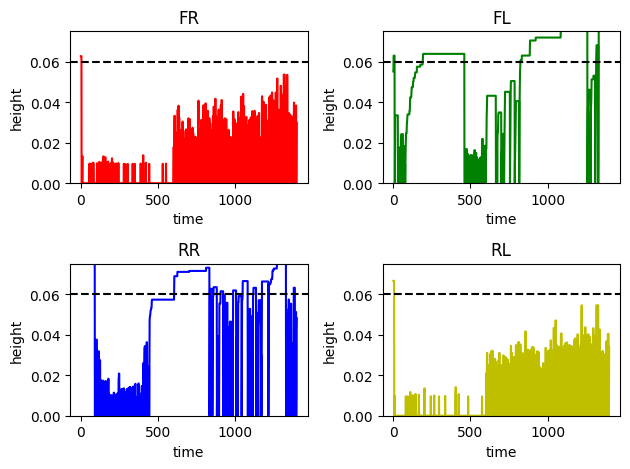

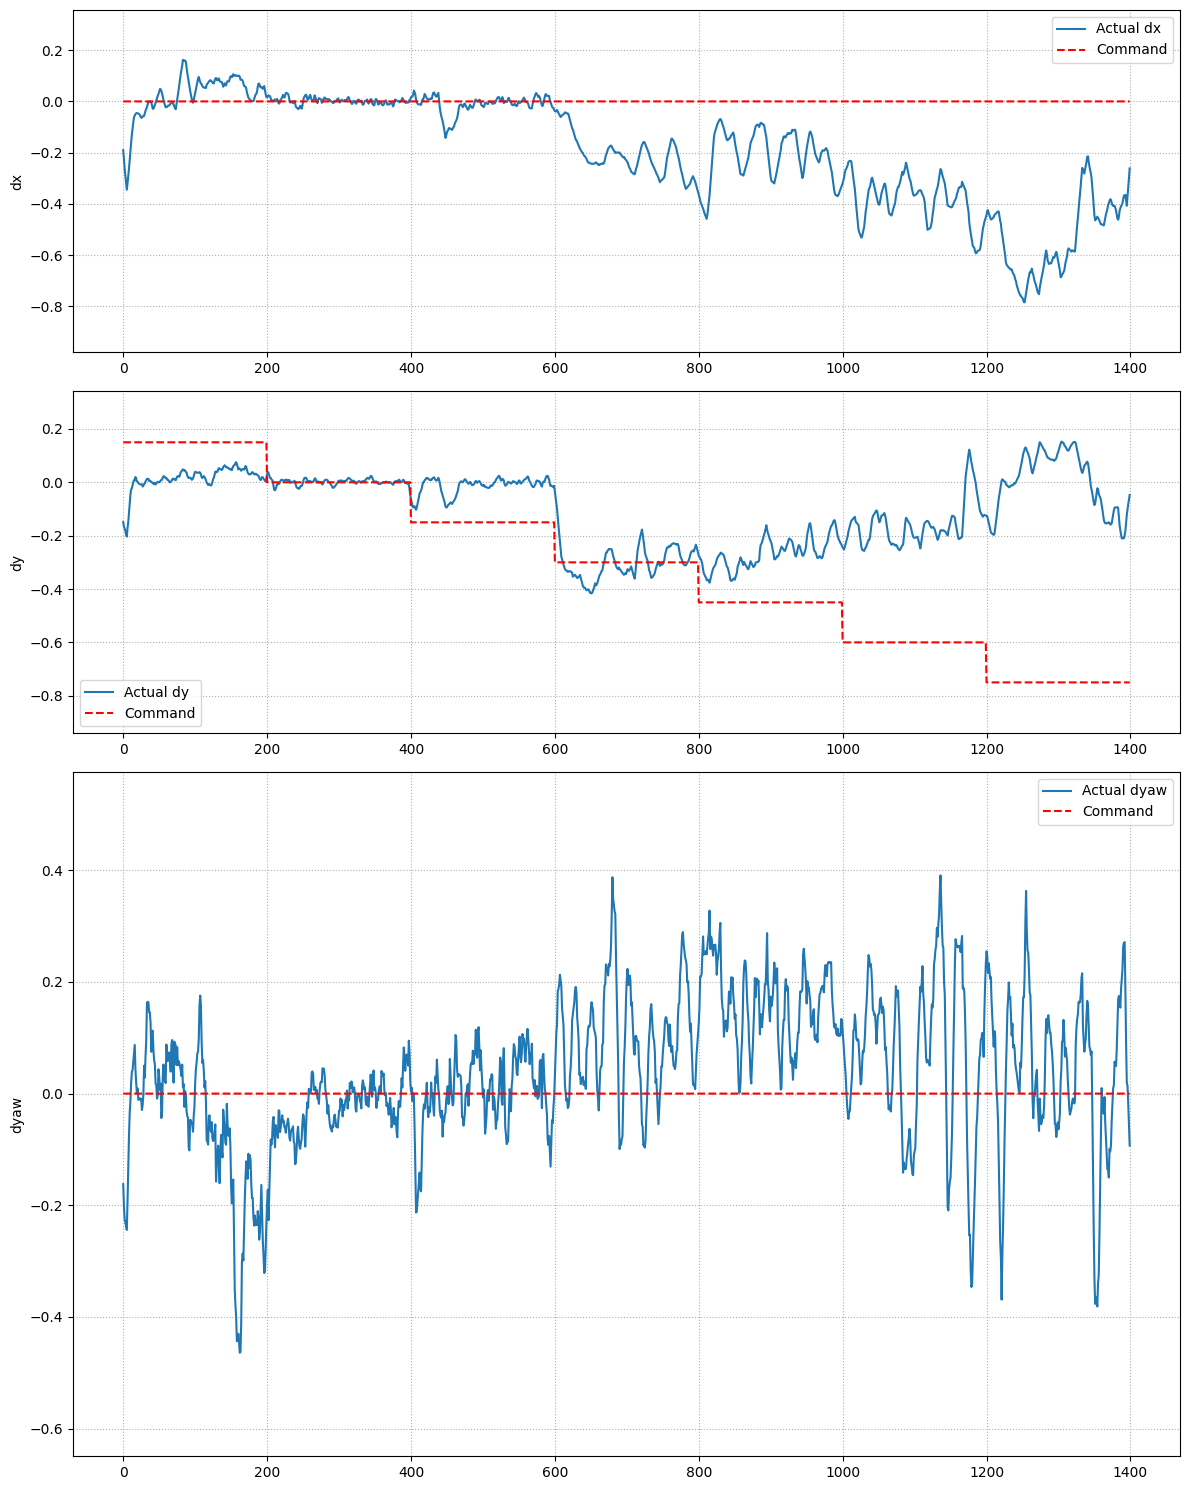

fps: 25.0


100%|██████████| 700/700 [00:26<00:00, 26.58it/s]


This browser does not support the video tag.


In [10]:
#@title Slowly increase linvel commands

rng = jax.random.PRNGKey(0)
rollout = []
modify_scene_fns = []
swing_peak = []
linvel = []
angvel = []
commands_history = []  # <<< 修改 1: 新增列表以記錄指令歷史

y = 0.15
command = jp.array([0, y, 0])
state = jit_reset(rng)
for i in range(1_400):
  # Increase the forward velocity by 0.25 m/s every 200 steps.
  # 修正邏輯，讓 y 從 i=0 的 0.25 開始，在 i=200 時變為 0.0
  if i > 0 and i % 200 == 0:
    y -= 0.15
    print(f"Setting y to {y}")
    command = jp.array([0, y, 0])

  state.info["command"] = command
  commands_history.append(command)  # <<< 修改 2: 在迴圈的每一步記錄當前指令

  if "steps_since_last_pert" in state.info and state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
    rng = sample_pert(rng)
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state)
  swing_peak.append(state.info["swing_peak"])
  linvel.append(env.get_global_linvel(state.data))
  angvel.append(env.get_gyro(state.data))
  xyz = np.array(state.data.xpos[env._torso_body_id])
  xyz += np.array([0, 0, 0.2])
  x_axis = state.data.xmat[env._torso_body_id, 0]
  yaw = -np.arctan2(x_axis[1], x_axis[0])
  modify_scene_fns.append(
      functools.partial(
          draw_joystick_command,
          cmd=command,
          xyz=xyz,
          theta=yaw,
          scl=abs(command[0]) / env_cfg.command_config.a[0] if env_cfg.command_config.a[0] != 0 else 0,
      )
  )

commands_history = jp.array(commands_history) # <<< 修改 3: 將指令歷史轉換為陣列

# Plot each foot in a 2x2 grid. (此部分不變)
swing_peak = jp.array(swing_peak)
names = ["FR", "FL", "RR", "RL"]
colors = ["r", "g", "b", "y"]
fig, axs = plt.subplots(2, 2)
for i, ax in enumerate(axs.flat):
  ax.plot(swing_peak[:, i], color=colors[i])
  ax.set_ylim([0, env_cfg.reward_config.max_foot_height * 1.25])
  ax.axhline(env_cfg.reward_config.max_foot_height, color="k", linestyle="--")
  ax.set_title(names[i])
  ax.set_xlabel("time")
  ax.set_ylabel("height")
plt.tight_layout()
plt.show()

# --- 以下是繪製 linvel 圖表的完整替換區塊 ---

linvel_x = jp.array(linvel)[:, 0]
linvel_y = -jp.array(linvel)[:, 1]
angvel_yaw = jp.array(angvel)[:, 2]

# Plot whether velocity is within the command range.
linvel_x = jp.convolve(linvel_x, jp.ones(10) / 10, mode="same")
linvel_y = jp.convolve(linvel_y, jp.ones(10) / 10, mode="same")
angvel_yaw = jp.convolve(angvel_yaw, jp.ones(10) / 10, mode="same")

# <<< 修改 4: 設定合理的畫布大小，並用 gridspec_kw 指定子圖高度比例
fig, axes = plt.subplots(
    3, 1, 
    figsize=(12, 15),  # 讓畫布整體比例更協調
    gridspec_kw={'height_ratios': [1, 1, 2]}  # 讓第三個圖的高度是第一、二個圖的兩倍
) 

data_series = [linvel_x, linvel_y, angvel_yaw]
labels = ["dx", "dy", "dyaw"]

for i, ax in enumerate(axes):
    data = data_series[i]
    command_line = commands_history[:, i]

    # <<< 修改 5: 繪製數據線和隨時間變化的指令線
    ax.plot(data, label=f'Actual {labels[i]}')
    ax.plot(command_line, color="red", linestyle="--", label='Command')
    
    # <<< 修改 6: 動態計算Y軸範圍，確保所有數據完整顯示
    min_val = min(data.min(), command_line.min())
    max_val = max(data.max(), command_line.max())
    # 增加 10% 的邊界讓圖表更好看
    margin = (max_val - min_val) * 0.1
    ax.set_ylim(min_val - margin - 0.1, max_val + margin + 0.1) # 加上一個小的絕對邊界以防margin為0

    ax.set_ylabel(labels[i])
    ax.legend()
    ax.grid(True, linestyle=':')

plt.tight_layout() # 自動調整子圖間距
plt.show() # 顯示圖表

# --- 替換區塊結束 ---


# 影片渲染部分保持不變
render_every = 2
fps = 1.0 / eval_env.dt / render_every
print(f"fps: {fps}")

traj = rollout[::render_every]
mod_fns = modify_scene_fns[::render_every]
assert len(traj) == len(mod_fns)

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = True

frames = eval_env.render(
    traj,
    camera="track",
    height=480,
    width=640,
    modify_scene_fns=mod_fns,
    scene_option=scene_option,
)
media.show_video(frames, fps=fps, loop=False)